# mSSA Run for one-armed phase spiral amplitude caused by both passages

In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
sys.path.append('../../code/')
import importlib
import helper

In [3]:
directory = '../../data/mssa_channels_B2/'

fname_m1_amp = directory+'m1_amp_bins_j30_t16.dat'
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j30_t16.dat'

# coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m1_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_amp)

# coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()

coefs = coefs_m1_amp0.deepcopy()
fname = fname_m1_amp

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [4]:
n_channels = int(len(coefs.getAllCoefs()))
times = coefs.Times()

keylst = [[i] for i in range(n_channels)]

config = {"m1_amp": (coefs, keylst, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

mssa = pyEXP.mssa.expMSSA(config, window, npc)

---- Eigen is using 4 threads


In [5]:
fig_dir = '../../figures/B2_figures/m1_amp_fiducial/'

In [6]:
ev = mssa.eigenvalues()

shape U = 86800 x 176
shape Y = 176 x 86800


In [7]:
coefs.zerodata()
mssa.reconstruct([*range(30)])

In [8]:
def make_ev_and_wCorr_plots(ev, mssa, fig_dir):
    fig, [ax1, ax2] = plt.subplots(1,2,figsize=(12,5))
    ax1.semilogy(ev[:50], '-o')
    ax1.set_xlabel('index', fontsize=20)
    ax1.set_ylabel('eigenvalue', fontsize=20)
    ax1.set_title('PC Eigenvalues', fontsize=20)

    ax2.imshow(mssa.wCorrAll(), cmap='gray_r')
    plt.tight_layout(pad=0)
    plt.savefig(fig_dir+'ev+wcorr.png')
    plt.show()

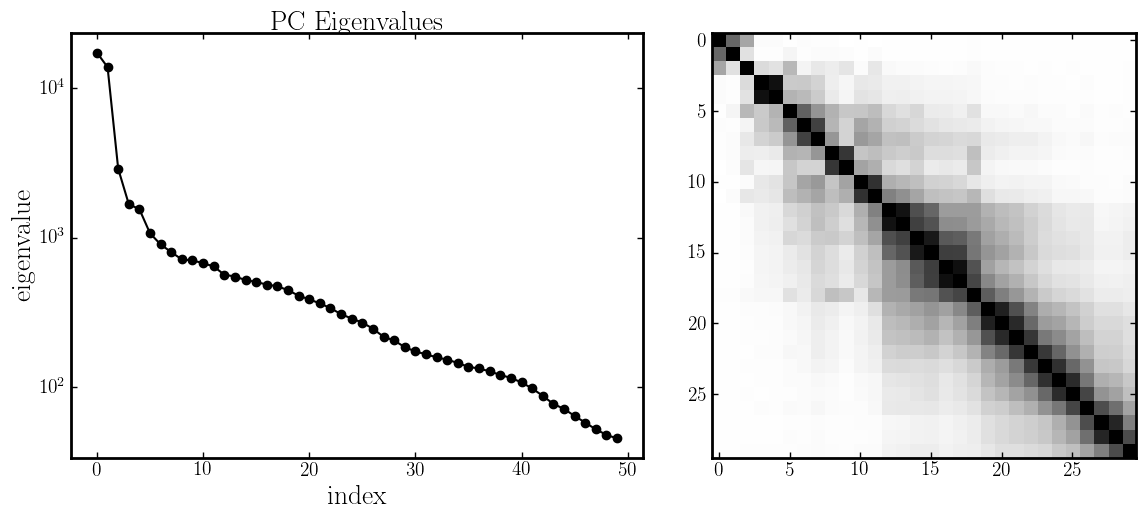

In [9]:
%matplotlib inline
make_ev_and_wCorr_plots(ev, mssa, fig_dir=fig_dir)

(250.0, 467.50000000000006)

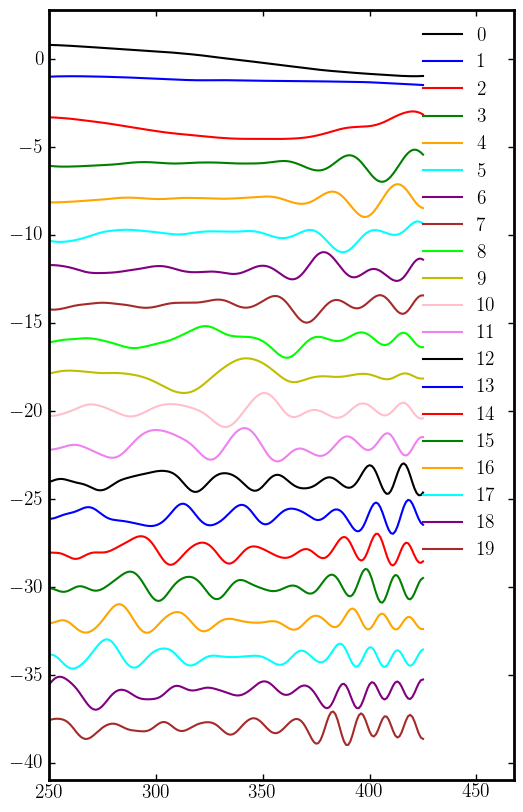

In [10]:
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

fig, ax = plt.subplots(1,1,figsize=(6,10))
for i in range(20):
    ax.plot(lag_times, pc[:,i] / np.max(np.abs(pc[:,i])) - 2*i, label=str(i))
ax.legend()
ax.set_xlim(np.min(lag_times), 1.1*np.max(lag_times))

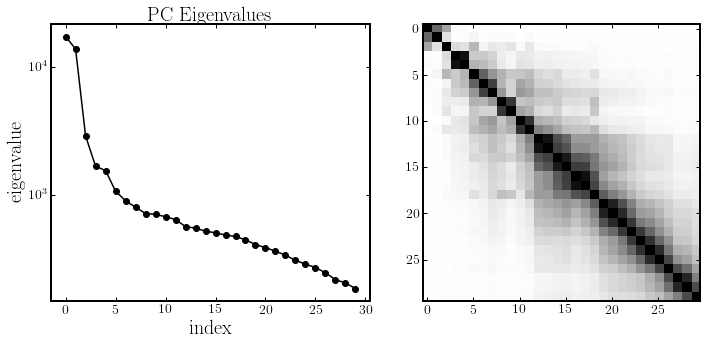

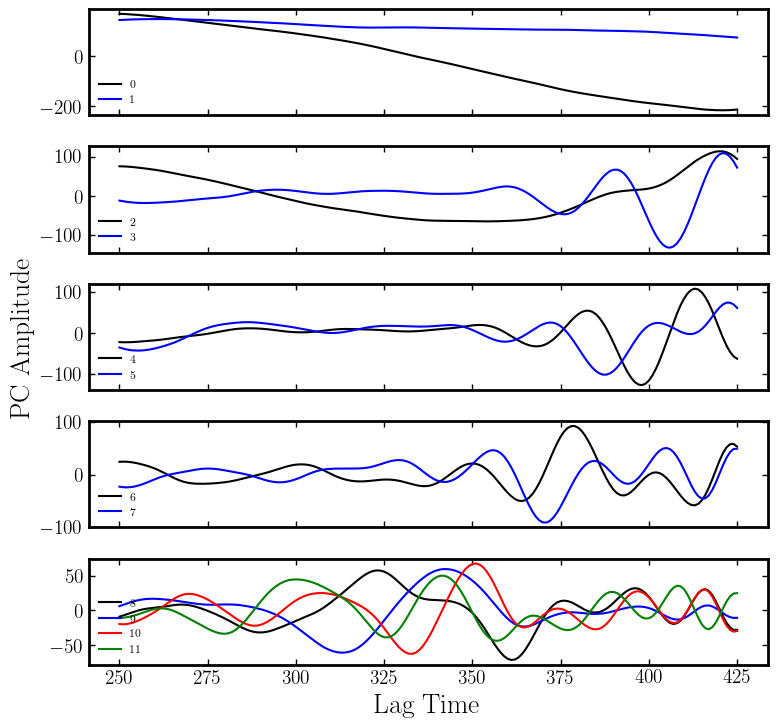

In [9]:
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(8, 1.5*n_plots), sharex=True)



for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

# plt.suptitle('PCs, m1 amp / m2 amp', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

axs[2].set_ylabel('PC Amplitude', fontsize=20)
for i in range(n_plots):
    axs[i].legend(fontsize=8, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

In [20]:
importlib.reload(sys.modules['helper'])
from helper import *

data_tbl = np.loadtxt(fname)

f = fig_dir+'face-on_plots/data_dark.mp4'
norm_function = mpl.colors.LogNorm
cmap = cmr.sunburst_r
vmin= 1e2 ; vmax=3e4

mpl.style.use('dark_background')
MakeAnim = MakeAnimations(mssa=mssa, sim_name='B2', channel_name='one-armed amplitude', times=times, jphi_min=1000, jbins=31)
MakeAnim.make_data_mov(f, data_tbl, norm_function=norm_function, cmap=cmap, vmin=vmin, vmax=vmax)

In [21]:
importlib.reload(sys.modules['helper'])
from helper import *

file_dir = fig_dir+'face-on_plots/dark_'

mpl.style.use('dark_background')
# for pc_list in list_of_pc_lists:
MakeAnim.reconstruct_from_pcs(pcs=list(range(2,12)))
MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                    norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst_r, vmin=vmin, vmax=vmax)
MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True, 
                                    norm_function=mpl.colors.SymLogNorm, cmap=cmr.prinsenvlag_r, vmin=-3e4, vmax=3e4, linthresh=1e2)

In [22]:
MakeAnim.reconstruct_from_pcs(pcs=list(range(12,27)))
MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                    norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst_r, vmin=vmin, vmax=vmax)
MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True, 
                                    norm_function=mpl.colors.SymLogNorm, cmap=cmr.prinsenvlag_r, vmin=-3e4, vmax=3e4, linthresh=1e2)

## Shorter window length

In [6]:
window_short = int(len(times)/4)

mssa_short = pyEXP.mssa.expMSSA(config, window_short, npc, flags)

In [7]:
fig_dir_short = '../../figures/B2_figures/m1_amp_window0p25/'

In [8]:
ev_short = mssa_short.eigenvalues()

shape U = 43152 x 264
shape Y = 264 x 43152


In [9]:
coefs.zerodata()
mssa_short.reconstruct([*range(30)])

In [10]:
make_ev_and_wCorr_plots(ev_short, mssa_short, fig_dir=fig_dir_short)

/var/folders/f1/wqzqbly11d9__jf5mjckhwvm0000gq/T/ipykernel_25190/2275262221.py:11: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()



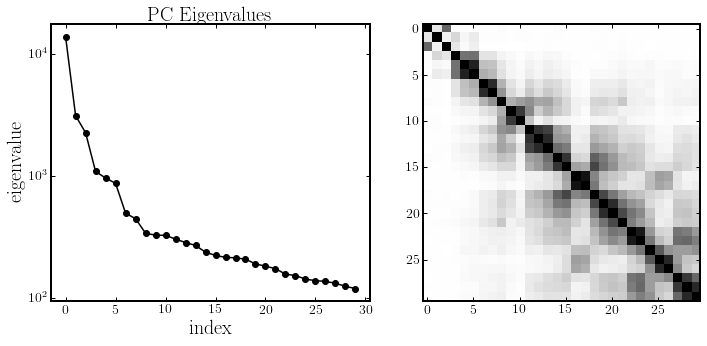

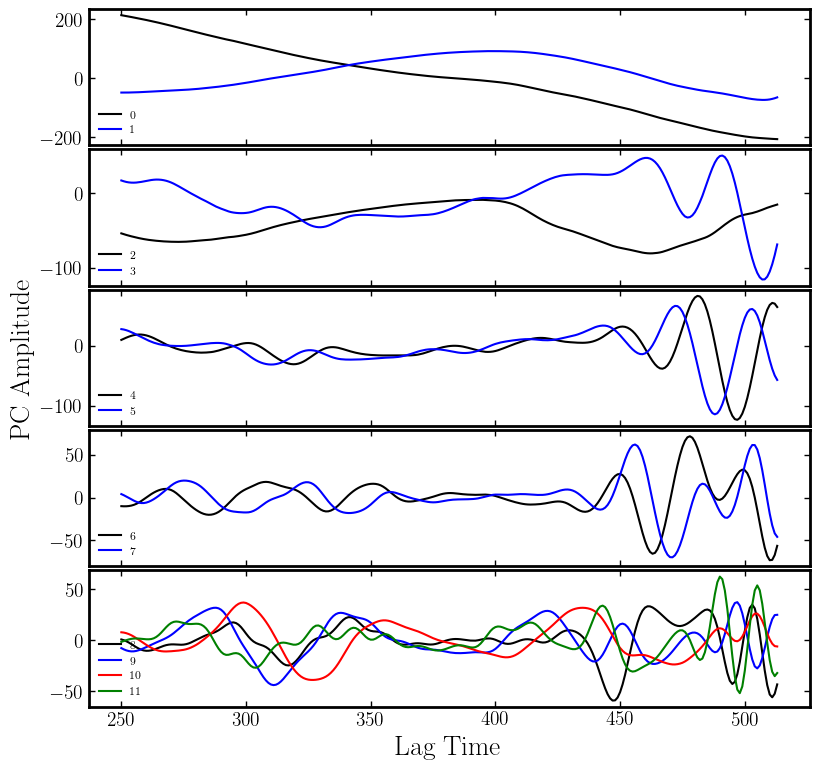

In [11]:
%matplotlib inline
pc = mssa_short.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(8, 1.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

# plt.suptitle('PCs, m1 amp / m2 amp', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

axs[2].set_ylabel('PC Amplitude', fontsize=20)
for i in range(n_plots):
    axs[i].legend(fontsize=8, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout(pad=0)
plt.savefig(fig_dir_short+'PCs.png')
#plt.savefig(fig_dir_short+'PCs.pdf') 
plt.show()

In [45]:
importlib.reload(sys.modules['helper'])
from helper import *

data_tbl = np.loadtxt(fname)

f = fig_dir_short+'face-on_plots/data.mp4'

vmin= 1e2 ; vmax=3e4

MakeAnim = MakeAnimations(mssa=mssa_short, sim_name='B2', channel_name='one-armed amplitude', times=times, jphi_min=1000, jbins=31)
MakeAnim.make_data_mov(f, data_tbl, norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst_r, vmin=vmin, vmax=vmax)

Updating for: (c)_0
Updating for: (s)_0
Updating for: ()_0
Updating for: (N)_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: (�)_0
Updating for: (g)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (>)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (0)_0
Updating for: (P)_0
Updating for: (�)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (6)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


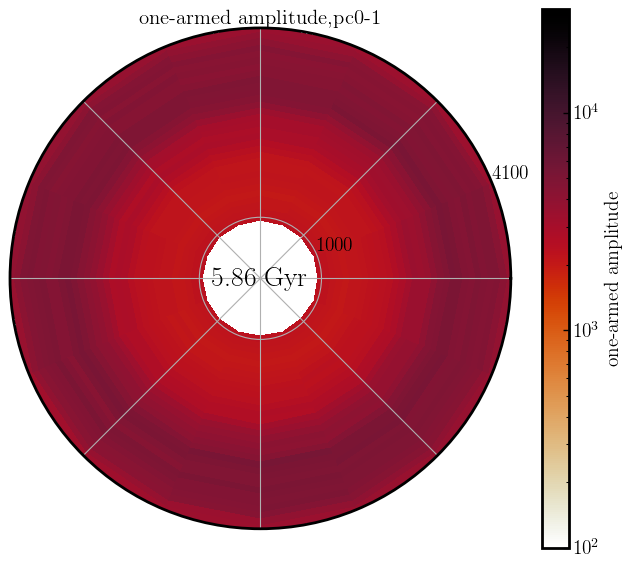

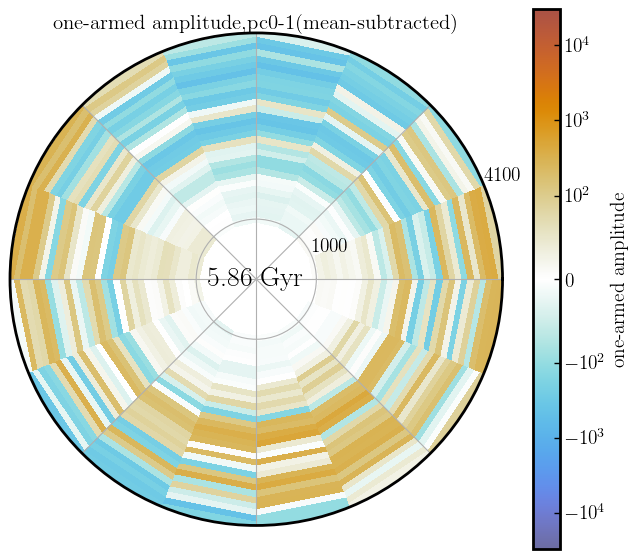

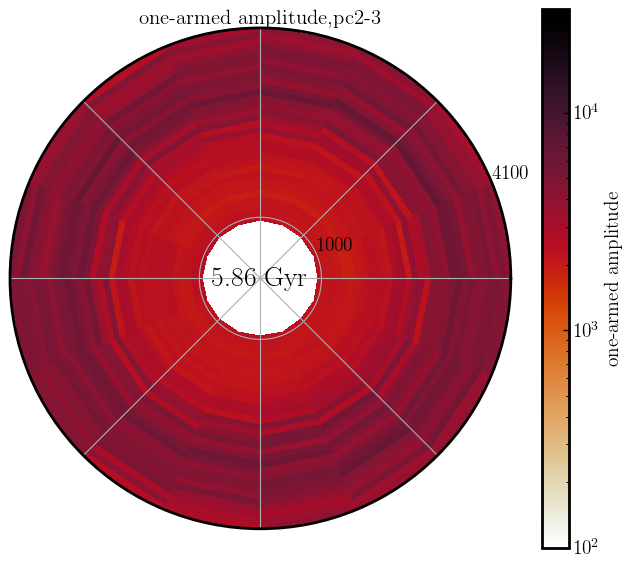

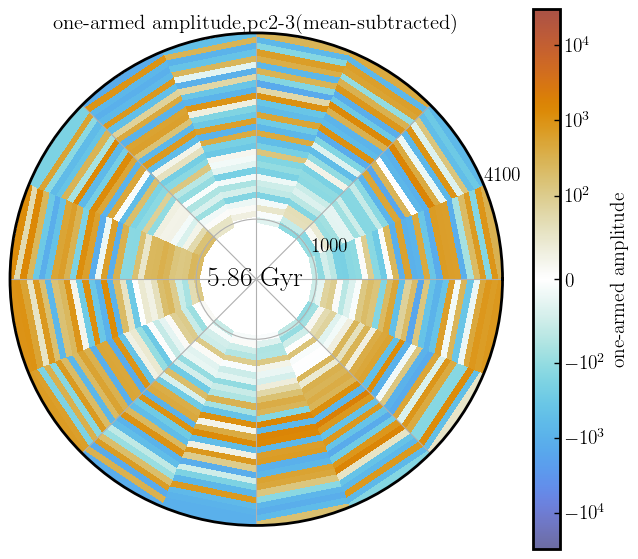

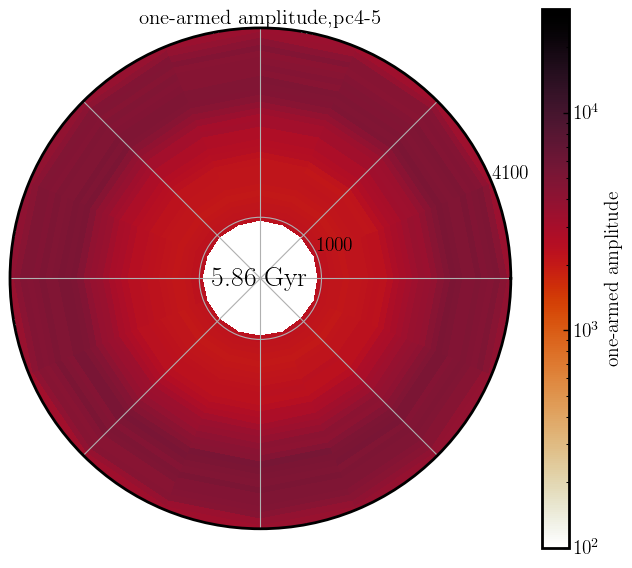

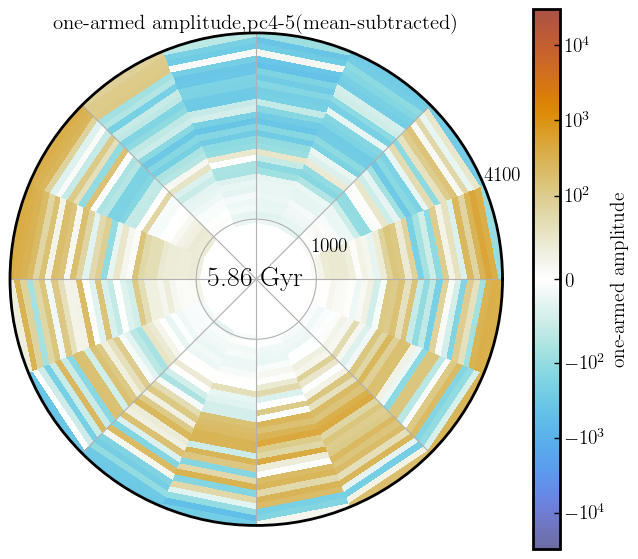

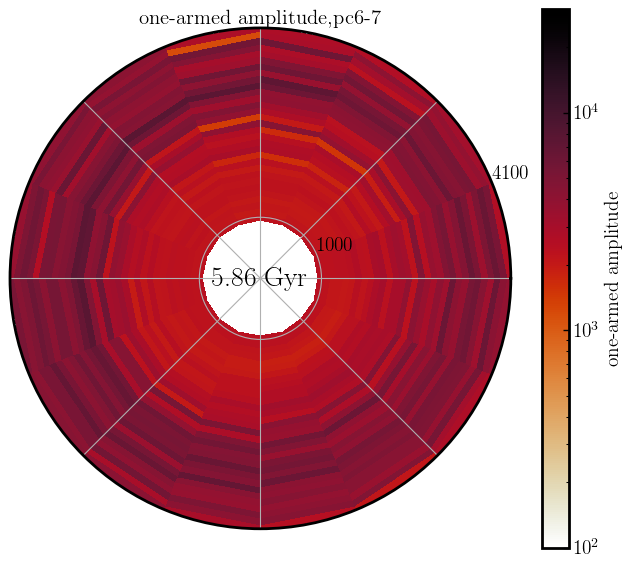

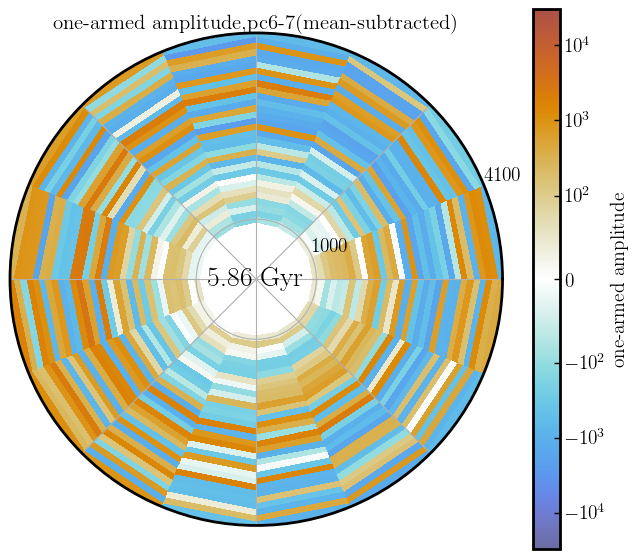

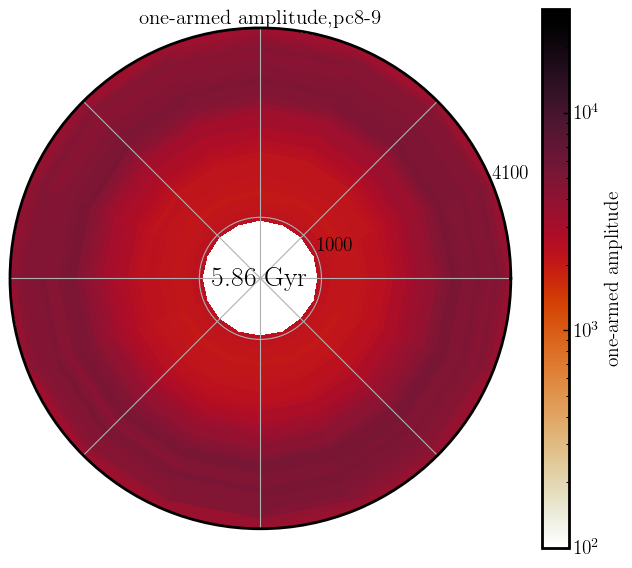

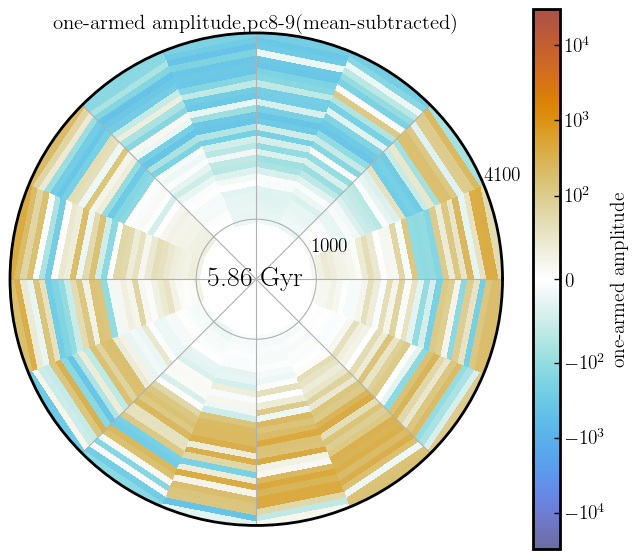

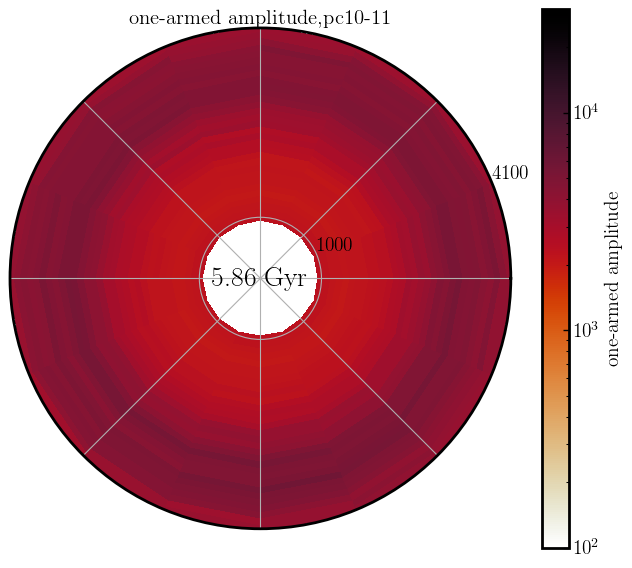

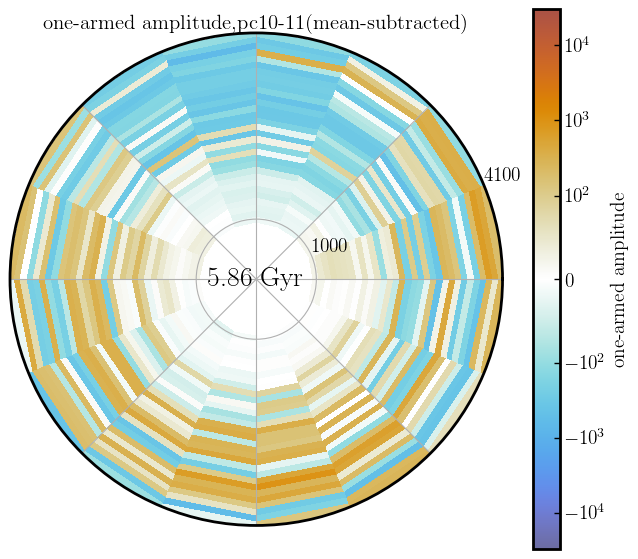

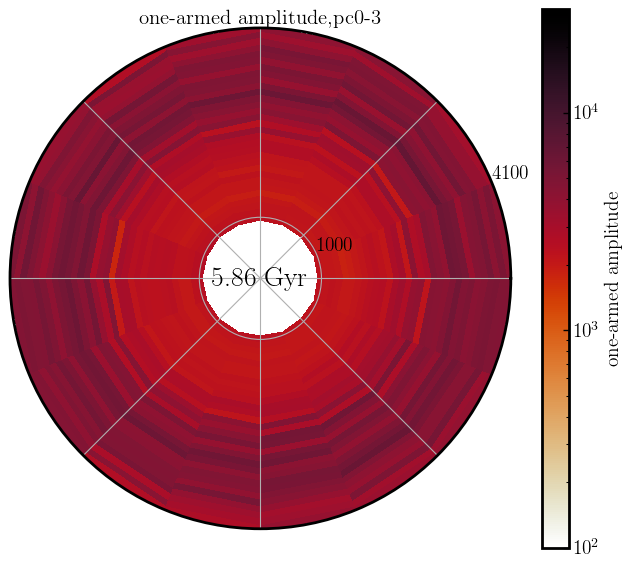

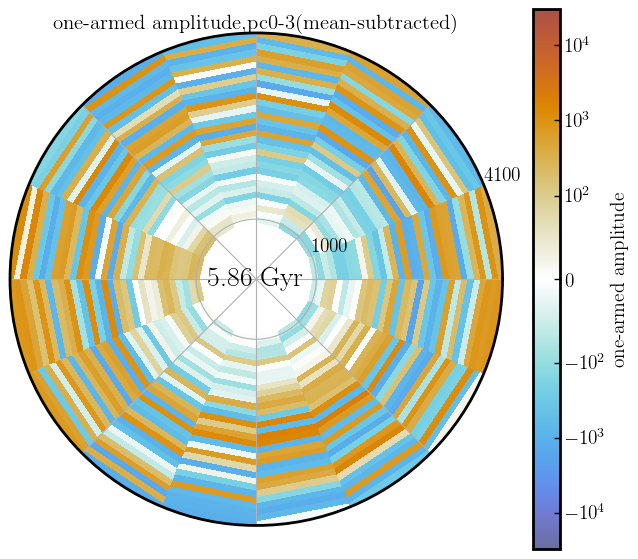

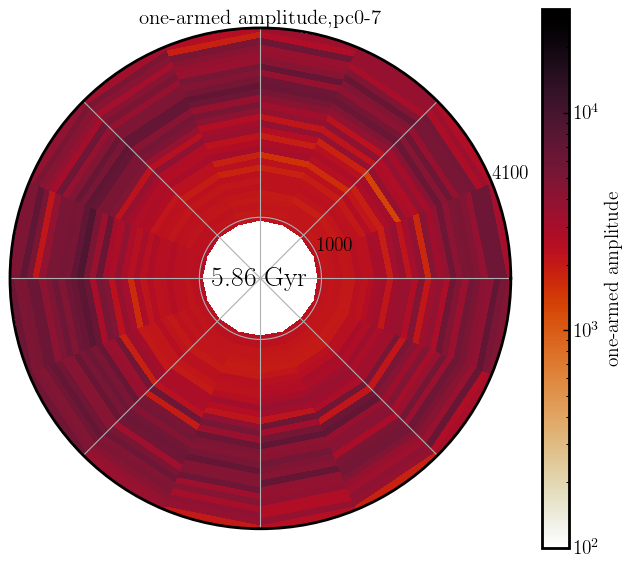

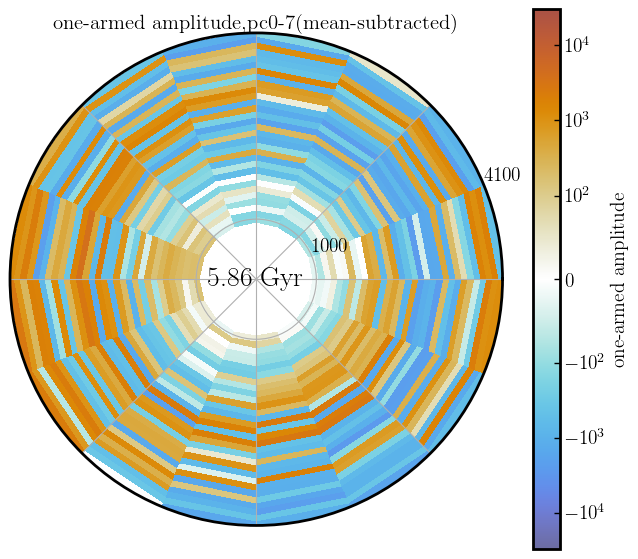

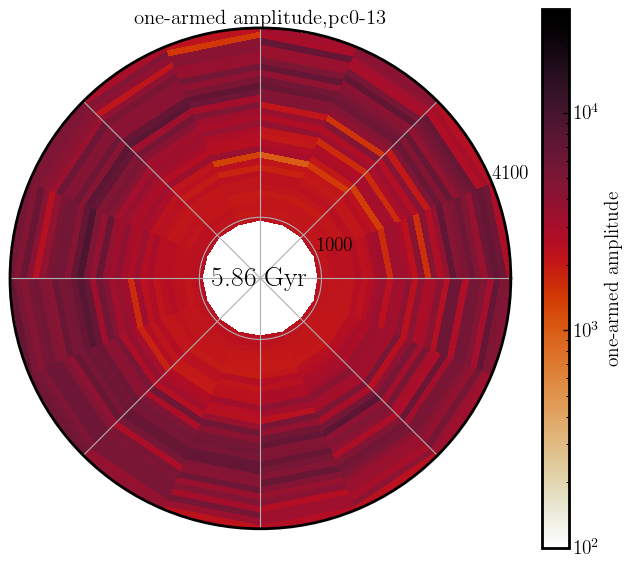

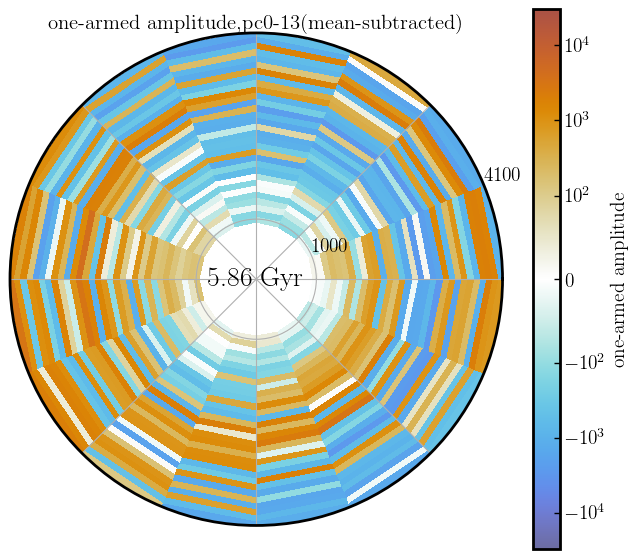

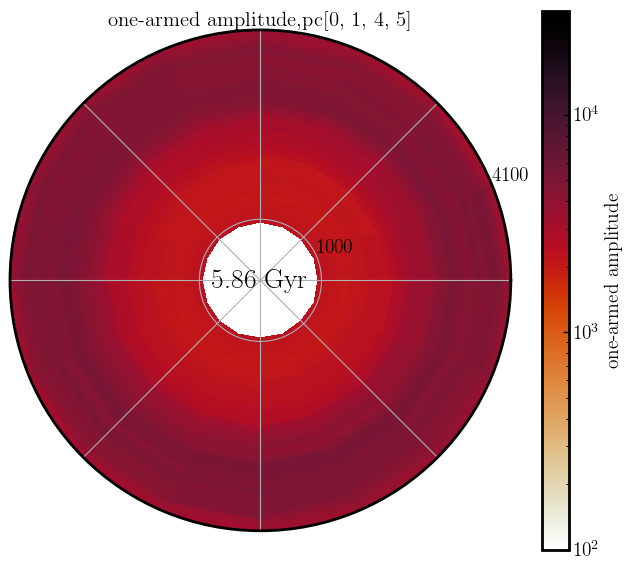

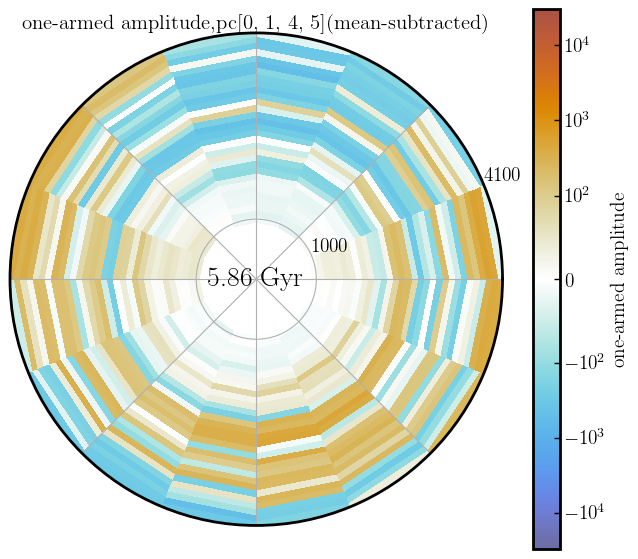

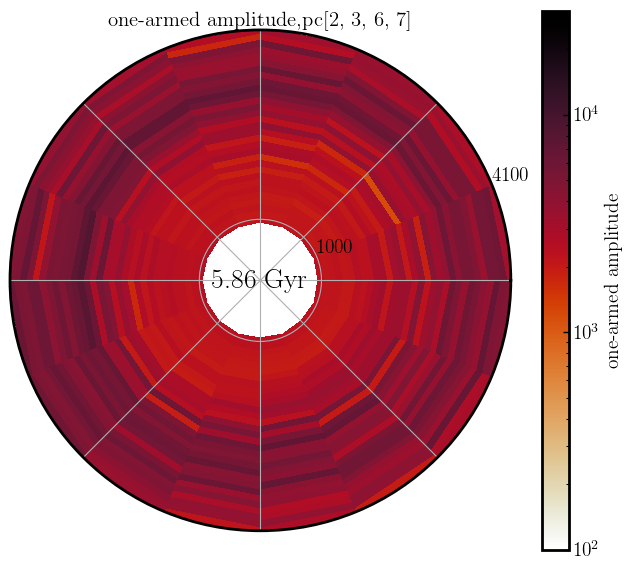

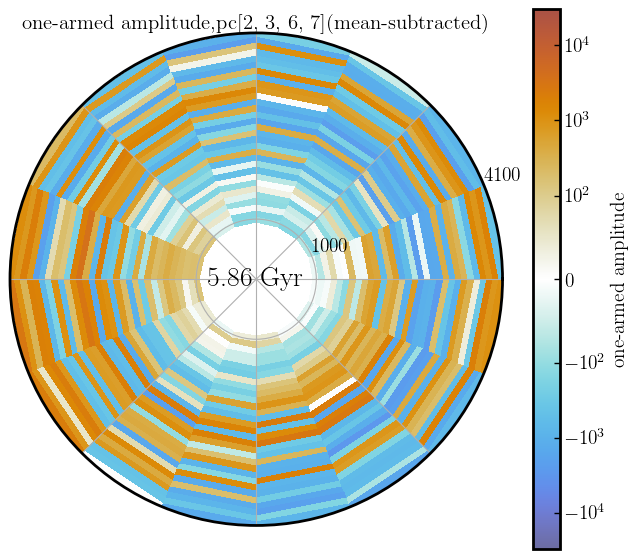

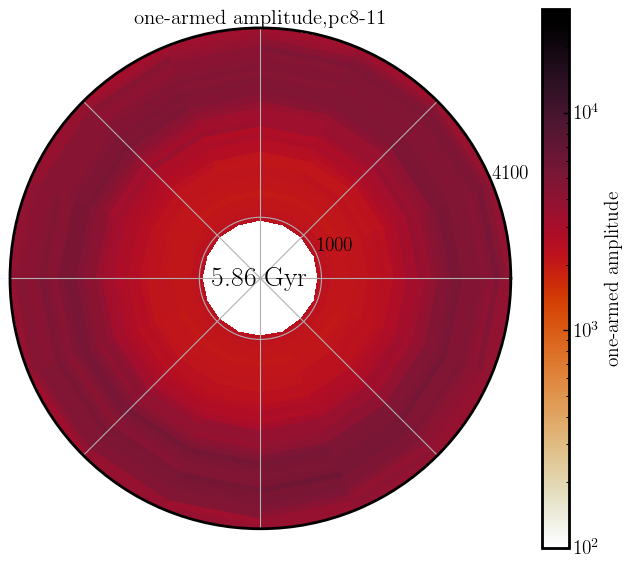

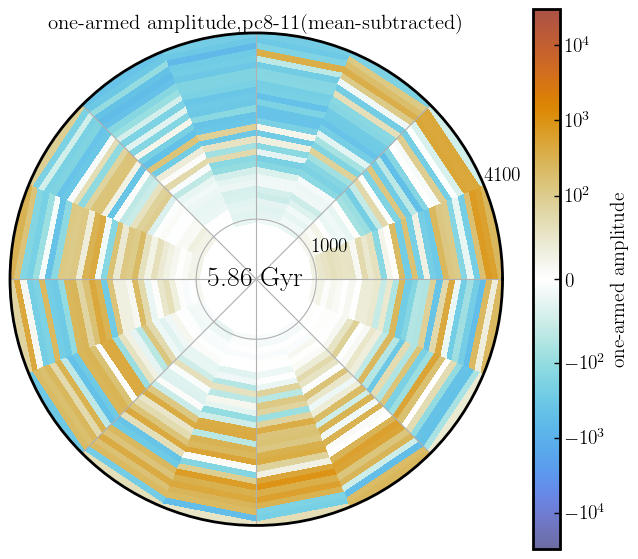

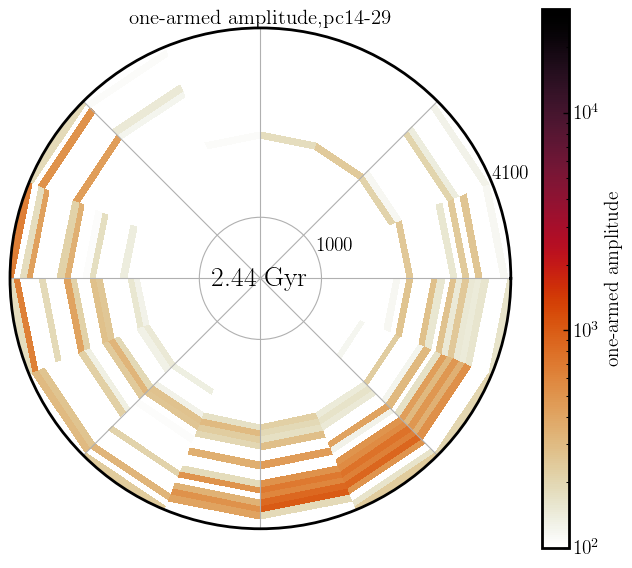

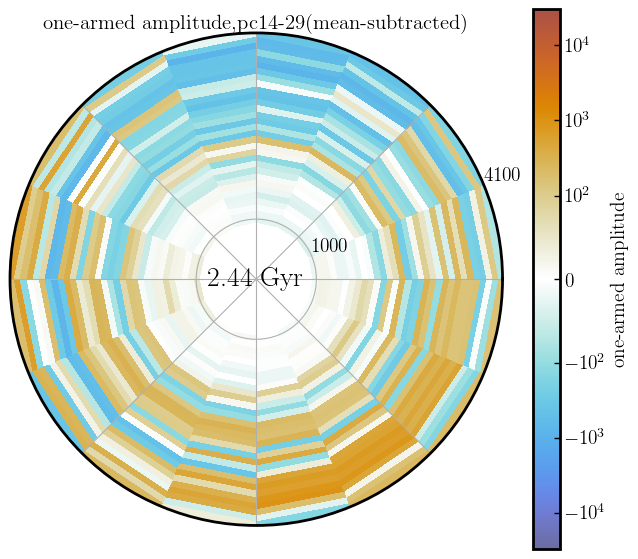

In [46]:
importlib.reload(sys.modules['helper'])
from helper import *

file_dir = fig_dir_short+'face-on_plots/'

list_of_pc_lists = list(([0,1], [2,3], [4,5], [6,7], [8,9], [10,11],
                         list(range(0,4)), list(range(0,8)), list(range(0,14)), 
                         [0,1,4,5], [2,3,6,7],
                         list(range(8,12)),
                         list(range(14,30))))

for pc_list in list_of_pc_lists:
    MakeAnim.reconstruct_from_pcs(pcs=pc_list)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                        norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst_r, vmin=vmin, vmax=vmax)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True, 
                                        norm_function=mpl.colors.SymLogNorm, cmap=cmr.prinsenvlag_r, vmin=-vmax, vmax=vmax, linthresh=vmin)